In [76]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames

In [77]:
using Revise
using Newtrinos
using Newtrinos.osc

In [125]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}(NNM(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All()), (m₀ = 0.1, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 40.0, r = 1.0), (m₀ = Uniform{Float64}(a=1.0e-7, b=0.015), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = Uniform{Float64}(a=3.0, b=100.0), r = Uniform{Float64}(a=0.0, b=1.0)), Newtrinos.osc.var"#get_Nnaturalness#52"(), Newtrinos.osc.var"#osc_prob#43"{Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}}(OscillationC

In [126]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics = (; osc, atm_flux, earth_layers);

In [127]:
experiments = (

  dayabay= Newtrinos.dayabay.configure(physics),
);

[ Info: Loading dayabay data


In [128]:
p = Newtrinos.get_params(experiments)

(N = 40.0, m₀ = 0.1, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [101]:
using Setfield

In [102]:
# modify the value of m0 with a random value taken from a Distribution

sigma= 2*p.m₀/10
new_m₀_un = rand(Uniform(p.m₀, p.m₀*(1+2/p.r))) 
new_m₀_norm= rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*(1+2/p.r)))
p_new_un = @set p.m₀ = new_m₀_un
p_new_norm = @set p.m₀ = new_m₀_norm


(N = 30.0, m₀ = 0.1091664735181506, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [103]:
assets= experiments.dayabay.assets

(E_arrs = [[1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43], [1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43], [1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43]], L_arrs = [[1919.63, 1917.52, 1925.26, 1894.34, 1891.98, 1899.86, 1533.18, 1534.92, 1538.93, 1533.63, 1535.03, 1539.47, 1551.38, 1554.77, 1556.34, 1524.94, 1528.05, 1530.08], [1919.63, 1917.52, 1925.26, 1923.15, 1894.34, 1891.98, 1899.86, 1897.51, 1533.18, 1534.92  …  1539.47, 1540.87, 1551.38, 1554.77, 1556.34, 1559.72, 1524.94, 1528.05, 1530.08, 1533.18], [1919.63, 1917.52, 1925.26, 1923.15, 1894.34, 1891.98, 1899.86, 1897.51, 1533.18, 1534.92  …  1539.47, 1540.87, 1551.38, 1554.77, 1556.34, 1559.72, 1524.94, 1528.05, 1530.08, 1533.18]], Npred_EH3_nooscs = [[966.99789101819, 1311.4889551891888, 1854.178347329635, 2317.3210980

In [104]:
expected_un = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
expected_un_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))


26-element Vector{Float64}:
 58843.96062641397
 61522.81967701944
 56524.09395030915
 69665.79356829953
 77888.1992123887
 86614.36619384574
 87388.17187265877
 82673.26173432112
 78328.03891986329
 73273.26291055622
 66080.42453671133
 59753.03526417014
 53834.341913817436
 49146.31059916749
 44646.521926280126
 39811.68368214938
 33466.09699068524
 34420.702912719964
 25285.7276579674
 19817.435201668348
 14689.027779719716
  9875.54130530948
  6407.964953869208
  6723.628252956689
  3683.974123934007
 17250.38159701726

In [105]:
expected_norm = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))
expected_norm_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))


26-element Vector{Float64}:
 58804.17045939999
 61656.07561933355
 56537.78777294821
 69674.15360944474
 77636.48428283693
 86648.22920677869
 87230.51348637356
 82589.99543975138
 78493.36963711194
 73171.3940155288
 66037.15927779
 59766.49632037603
 53865.62362174691
 49051.88069506769
 44634.15361961555
 39764.88195103818
 33480.494839225896
 34462.73239048793
 25279.681567996297
 19788.94005834349
 14653.060424016132
  9871.462068626737
  6417.23298627914
  6747.428558938931
  3691.2276630260976
 17176.69467658923

In [106]:
using CairoMakie

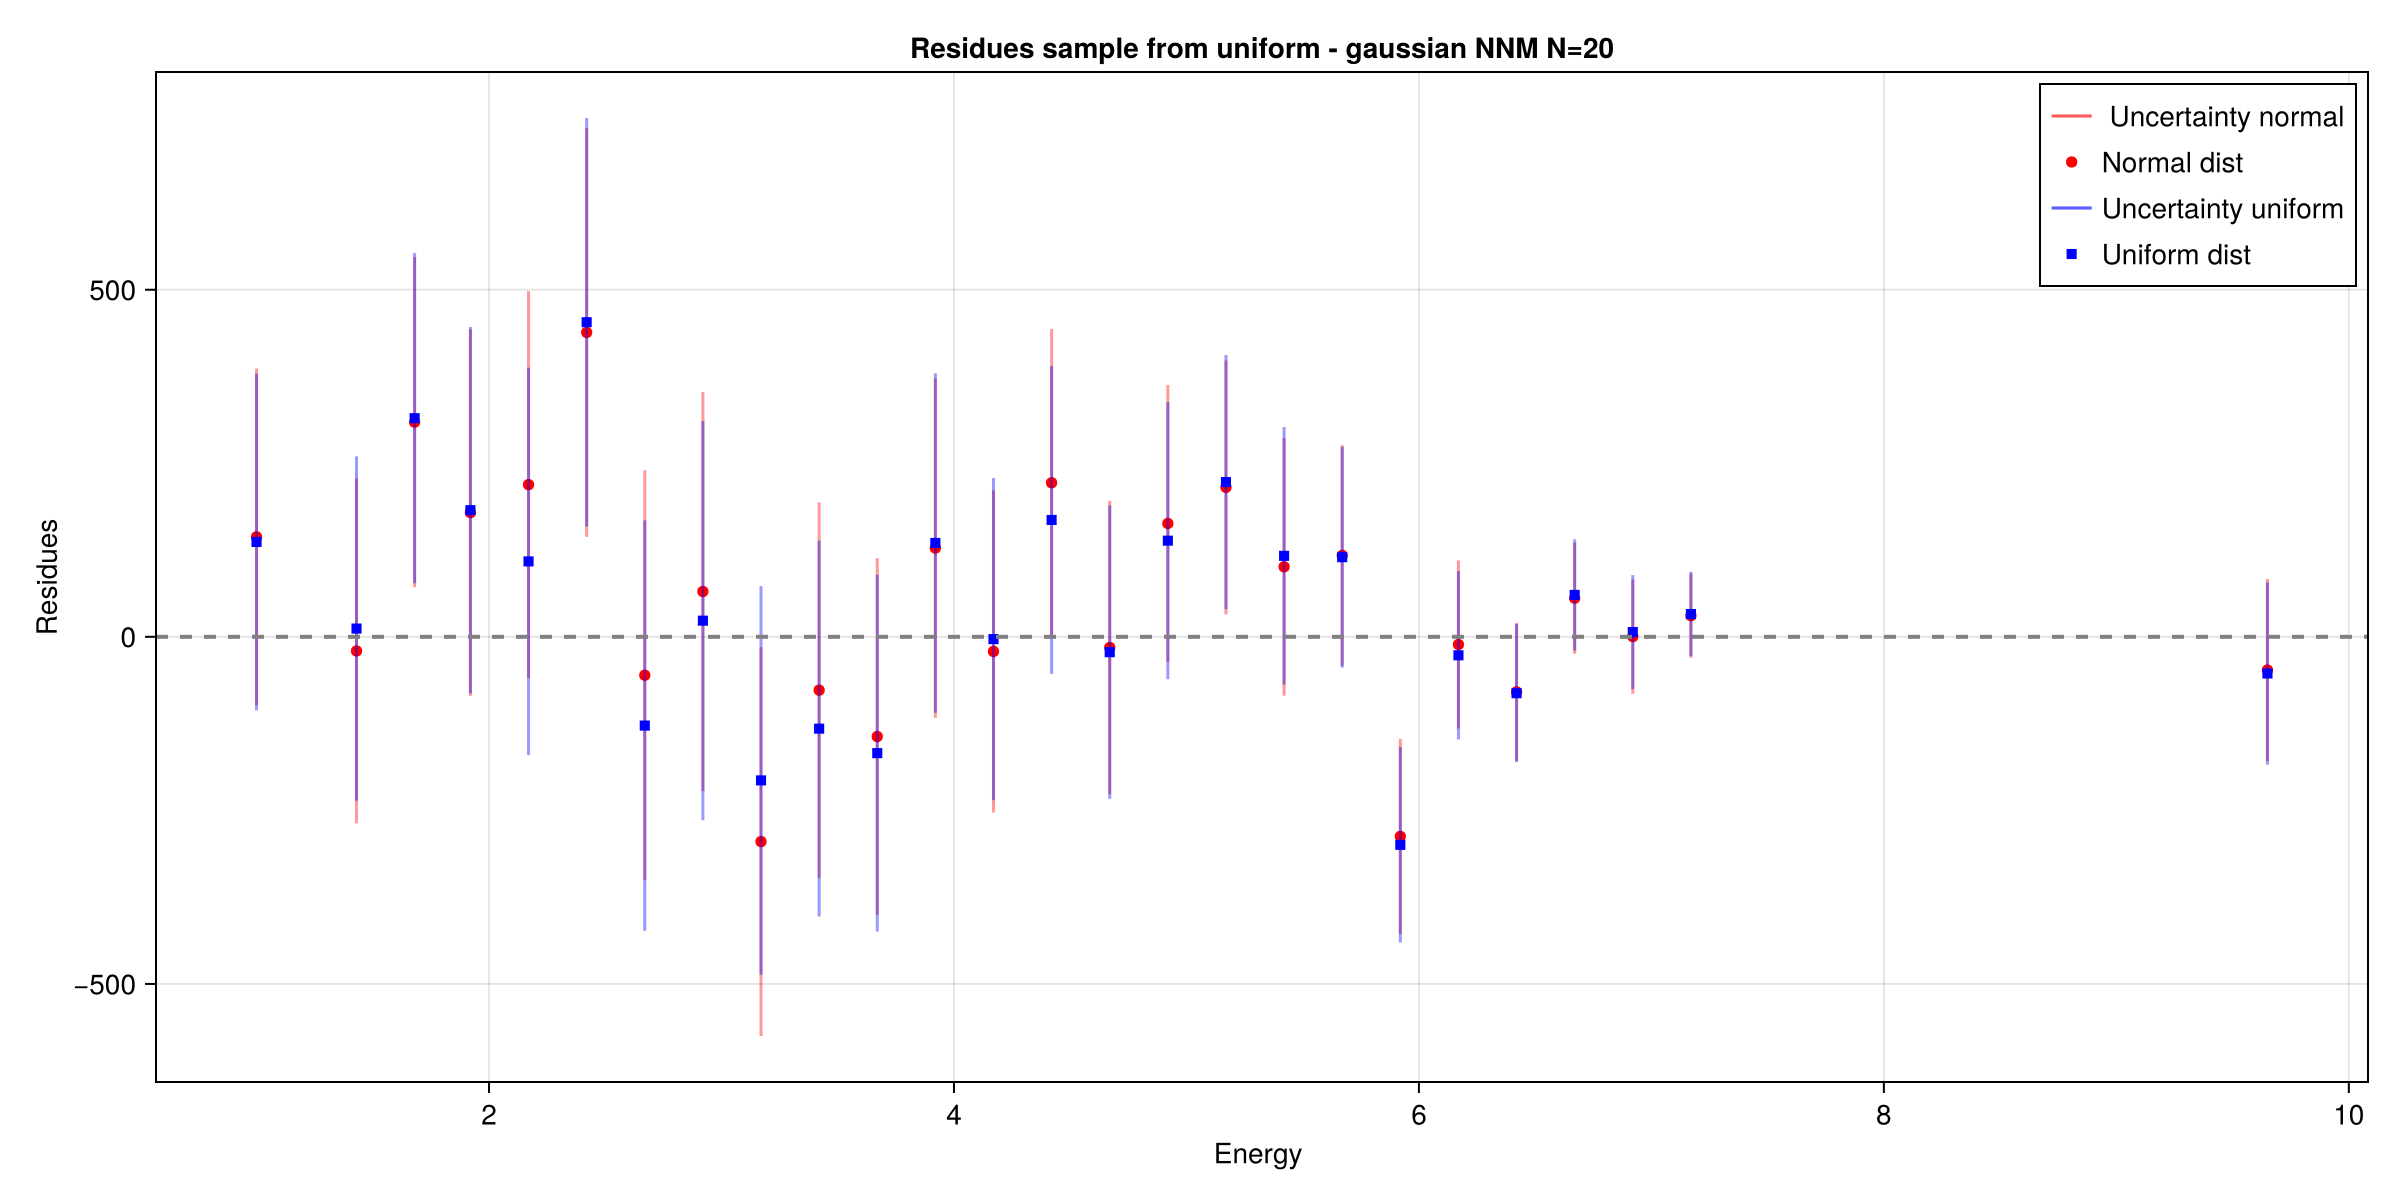

CairoMakie.Screen{IMAGE}


In [107]:

# Create the figure
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "Energy ",
    ylabel = "Residues", 
    title = "Residues sample from uniform - gaussian NNM N=20")


errorbars!(ax, assets.energy,  assets.observed-expected_norm,  sqrt.(expected_norm_var), 
      color = (:red, 0.4), label = " Uncertainty normal")

scatter!(ax, assets.energy,  assets.observed-expected_norm, 
        color = :red, markersize = 8, label = "Normal dist")

errorbars!(ax, assets.energy,  assets.observed-expected_un,sqrt.(expected_un_var), 
      color = (:blue, 0.4), label = "Uncertainty uniform")
      
scatter!(ax, assets.energy, assets.observed-expected_un, 
        color = :blue, marker = :rect, markersize = 8,label = "Uniform dist")

        
# Add a horizontal line at zero for reference
hlines!(ax, [0], color = :gray, linestyle = :dash, linewidth = 2)

    
# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/dayabay/nm_dayabay_NNM_N30_residues.png", fig)

In [108]:
#img = experiments.dayabay.plot(p_new_norm)
#display("image/png", img)

In [118]:

using ProgressMeter
using MeasureBase

In [131]:
function random_sampling(physics, experiments, p)

   chi_squared_un_list = Float64[]
   chi_squared_norm_list = Float64[]

   @showprogress for i in 1:100
      #println("Random sampling iteration: $i")
      sigma=2*p.m₀/100
      new_m₀_un = rand(Uniform(p.m₀, p.m₀*(1+2/p.r))) 
      new_m₀_norm=rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*(1+2/p.r)))
      p_new_un = @set p.m₀ = new_m₀_un
      p_new_norm = @set p.m₀ =new_m₀_norm

      assets= experiments.dayabay.assets
      observed = assets.observed

      expected_un = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
      expected_un_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
      expected_norm = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))
      expected_norm_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))

      #chi_squared_un = sum((observed.- expected_un).^2 ./ expected_un_var)
      #chi_squared_norm = sum((observed.- expected_norm).^2 ./ expected_norm_var)
      likelihood_norm=logdensityof(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm), observed)
      likelihood_un=logdensityof(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un), observed)

      push!(chi_squared_un_list, likelihood_un)
      push!(chi_squared_norm_list, likelihood_norm)

   end
   return chi_squared_un_list, chi_squared_norm_list
end

random_sampling (generic function with 1 method)

In [132]:
trial=random_sampling(physics, experiments, p)

Progress:   8%|███▎                                     |  ETA: 0:16:40

LoadError: InterruptException:

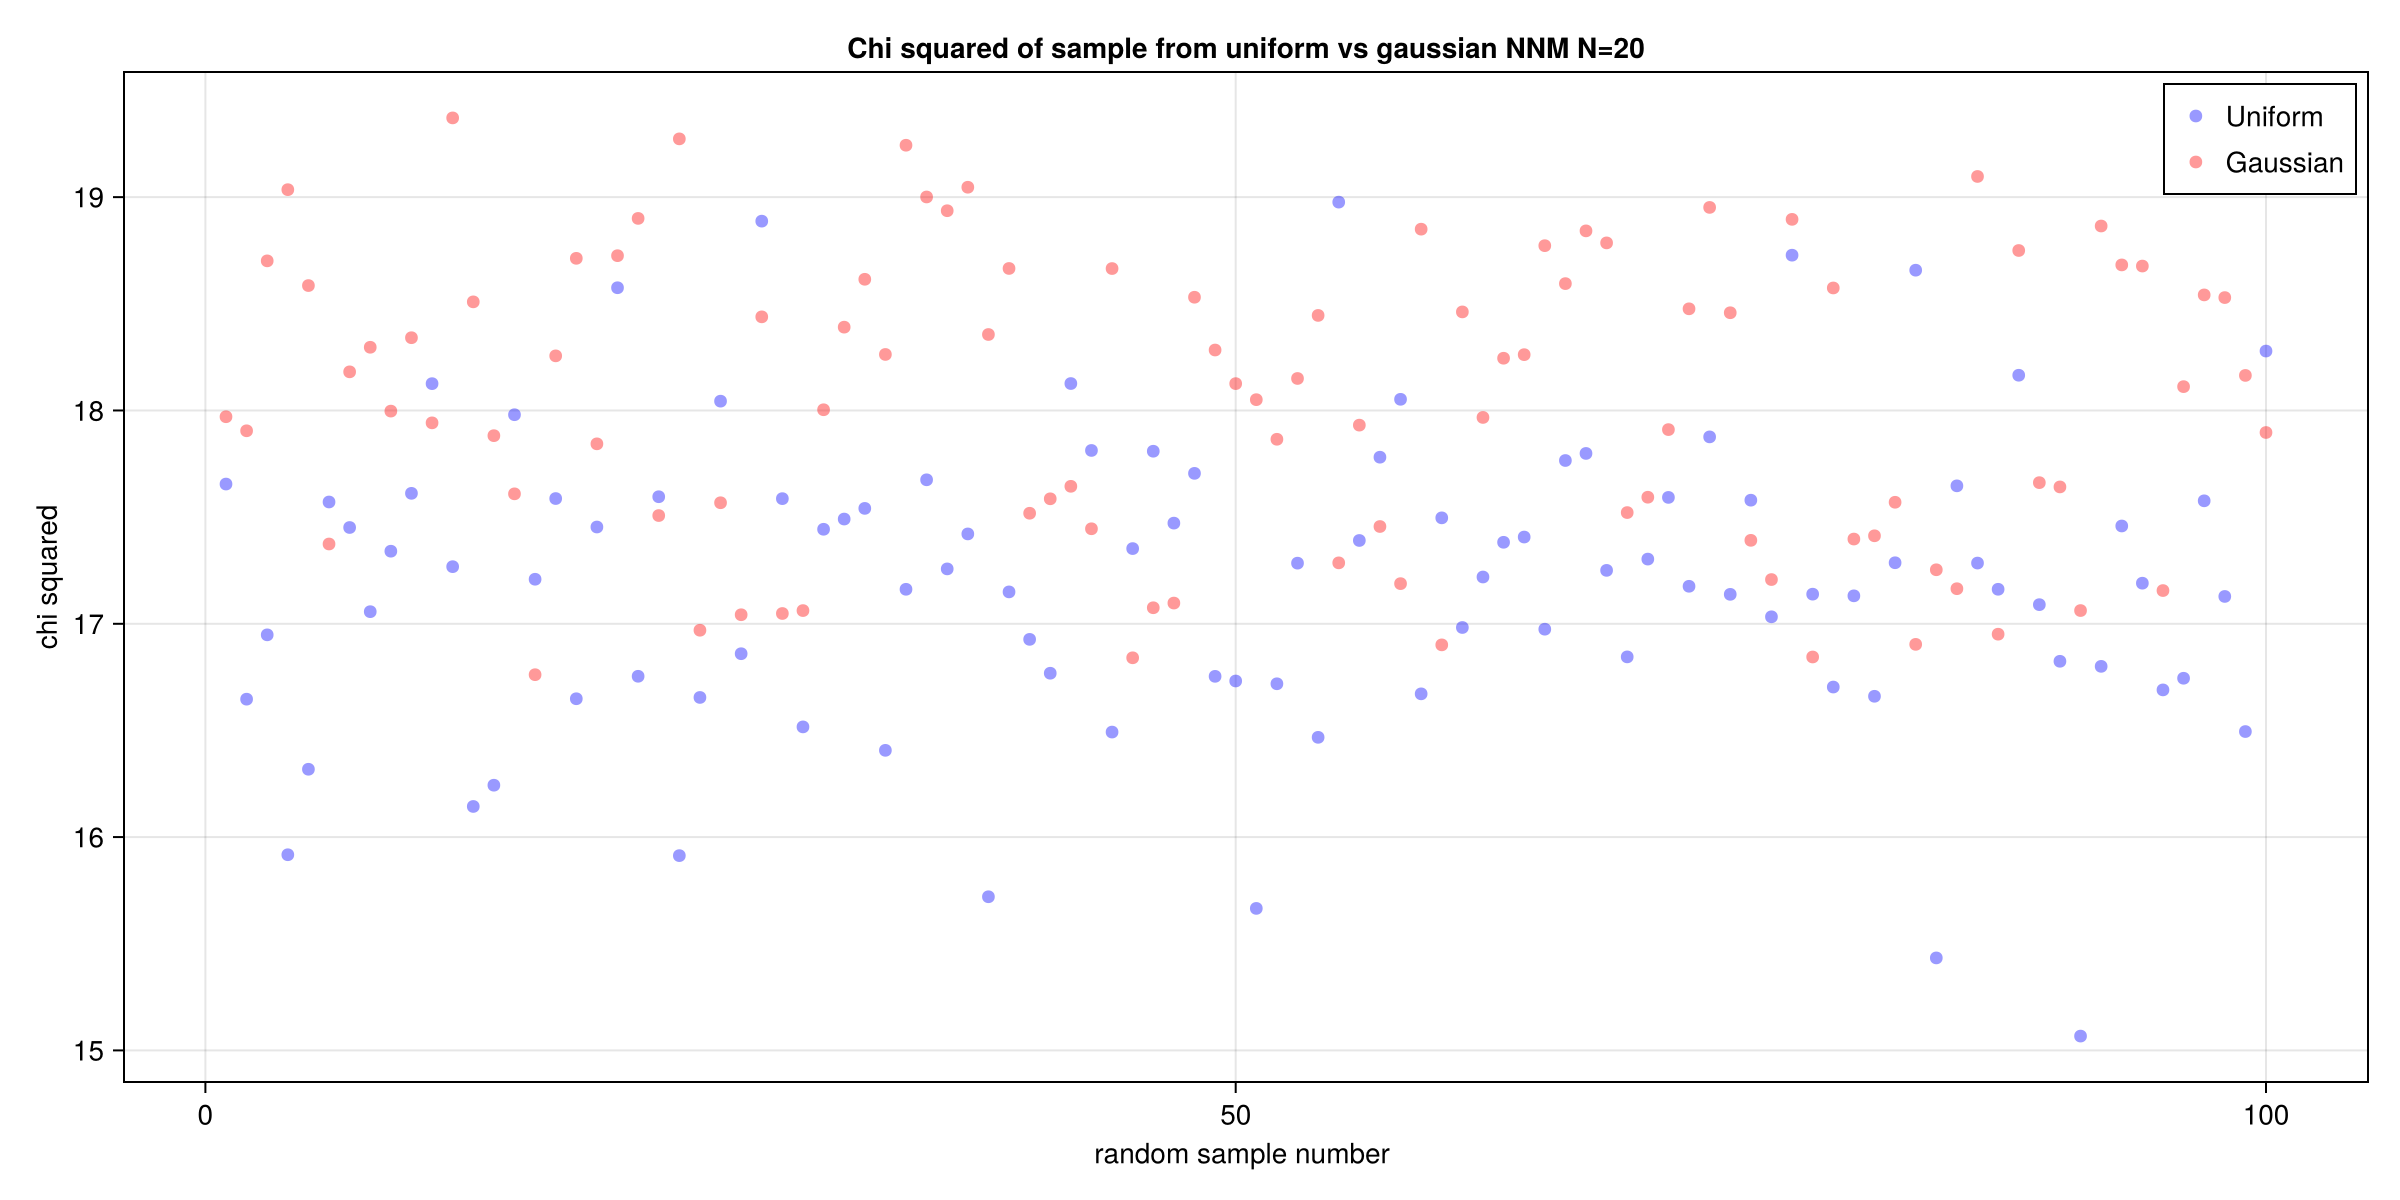

CairoMakie.Screen{IMAGE}


In [112]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "random sample number ",
    ylabel = "chi squared", 
    title = "Chi squared of sample from uniform vs gaussian NNM N=20")
scatter!(ax, 1:100, trial[1], color = (:blue, 0.4), label = "Uniform")
scatter!(ax, 1:100, trial[2], color = (:red, 0.4), label = "Gaussian")

   
# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/dayabay/nm_dayabay_NNM_N20_m0=0.1_chi.png", fig)